In [94]:
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
import pandas as pd
import matplotlib.pyplot as plt



In [ ]:
df=pd.read_csv("bank_transactions_data_2_augmented_clean_2.csv")

In [ ]:
df.head()

### Cleaning Data

In [ ]:
# Null check
print(df.isnull().sum().sort_values(ascending=False))

In [ ]:
# Duplicate check
print("Duplicate rows:", df.duplicated().sum())

In [ ]:
print(df.shape)

In [ ]:
print(df["TransactionDate"].head())
print(df["TransactionDate"].dtype)

In [ ]:
# Rename columns
df.columns = [
    "transaction_id",
    "account_id",
    "transaction_amount",
    "transaction_date",
    "transaction_type",
    "location",
    "device_id",
    "ip_address",
    "merchant_id",
    "channel",
    "customer_age",
    "customer_occupation",
    "transaction_duration",
    "login_attempts",
    "account_balance"
]

print(df.columns.tolist())

In [ ]:
cat_cols = ["transaction_type", "location", "channel", "customer_occupation"]

for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

In [ ]:
for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts().head(10))

In [ ]:
num_cols = [
    "transaction_amount",
    "customer_age",
    "transaction_duration",
    "login_attempts",
    "account_balance"
]

print(df[num_cols].describe())

In [ ]:
cat_cols = ["transaction_type", "location", "channel", "customer_occupation"]

for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

In [ ]:
X = df.drop(columns=[
    "transaction_id",
    "account_id",
    "transaction_date",
    "device_id",
    "ip_address",
    "merchant_id"
], errors="ignore")

In [ ]:
print(X.head())
print(X.columns.tolist())
print(X.dtypes)

### Preprocessing

In [ ]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

In [ ]:
# Handling numerical variables
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [ ]:
# Handling categorical variables
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


In [ ]:
X_processed = preprocessor.fit_transform(X)

In [ ]:
print(X_processed.shape)

### Modeling

In [ ]:
iso = IsolationForest(
    n_estimators=200,
    contamination=0.01,
    random_state=42
)


In [ ]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.01
)

In [ ]:
iso_pred = iso.fit_predict(X_processed)
lof_pred = lof.fit_predict(X_processed)

In [ ]:
df["iso_anomaly"] = (iso_pred == -1).astype(int)
df["lof_anomaly"] = (lof_pred == -1).astype(int)

In [ ]:
print("Isolation Forest anomalies:", df["iso_anomaly"].sum())
print("LOF anomalies:", df["lof_anomaly"].sum())

### Assessing Model

In [ ]:
overlap = ((df["iso_anomaly"] == 1) & (df["lof_anomaly"] == 1)).sum()
print("Overlap anomalies:", overlap)

In [ ]:
iso_anomalies = df[df["iso_anomaly"] == 1]
lof_anomalies = df[df["lof_anomaly"] == 1]

print("Isolation Forest anomalies:")
print(iso_anomalies.head(10))

print("\nLOF anomalies:")
print(lof_anomalies.head(10))

LOF was less suitable for this dataset because many of the transactions it flagged did not appear suspicious from a fraud perspective. Several detected anomalies involved low transaction amounts, single login attempts, and account balances that comfortably supported the transaction, making them less meaningful as potential fraud cases.

Isolation forest seems to be the most suitable since it successfully capture suspicious signs of potential froud such as unusually high login attempts, high saction amount compared to account balance

In [ ]:
# Normal vs suspicious transaction
print(df.groupby("iso_anomaly")[[
    "transaction_amount",
    "login_attempts",
    "account_balance",
    "amount_balance_ratio",
    "transaction_duration",
    "customer_age"
]].mean())

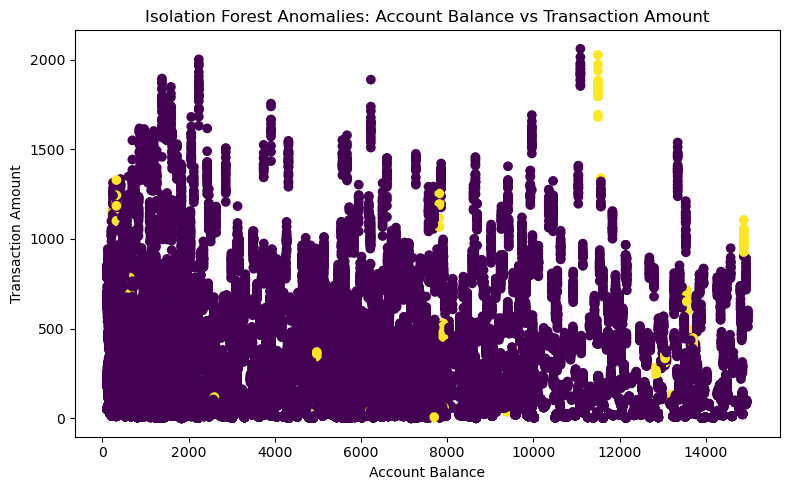

In [93]:

plt.figure(figsize=(8,5))
plt.scatter(df["account_balance"], df["transaction_amount"], c=df["iso_anomaly"])
plt.xlabel("Account Balance")
plt.ylabel("Transaction Amount")
plt.title("Isolation Forest Anomalies: Account Balance vs Transaction Amount")
plt.tight_layout()
plt.show()

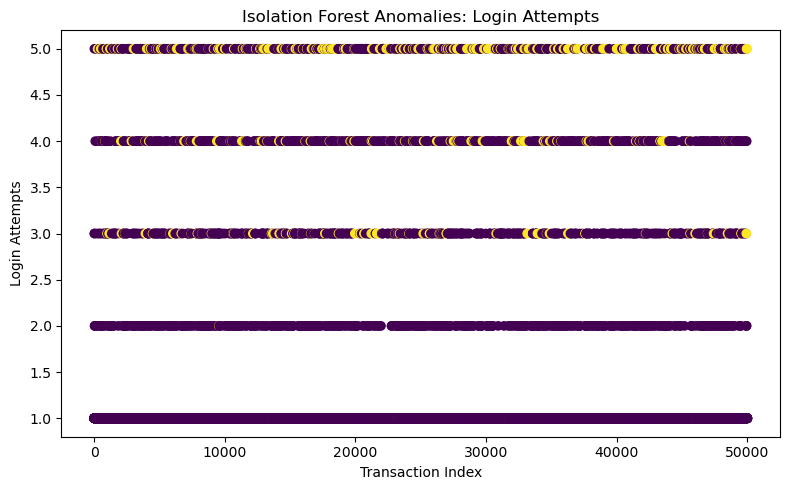

In [92]:
plt.figure(figsize=(8,5))
plt.scatter(df.index, df["login_attempts"], c=df["iso_anomaly"])
plt.xlabel("Transaction Index")
plt.ylabel("Login Attempts")
plt.title("Isolation Forest Anomalies: Login Attempts")
plt.tight_layout()
plt.show()

2 models shows the same amount of suspicious transactions. However, they do not overlap. Isolation Forest provides more plausible suspicious transaction involving repeated login attempts and transaction amounts that were high relative to account balance. LOF, by contrast, often flagged low-value transactions with normal account balances and single login attempts. Therefore, Isolation Forest was selected as the final model.